# Time Series Analysis of IBM Stock (2013–2018)

This project performs a univariate time series analysis on the closing price of IBM stock.

## Objectives:
- Visualise stock price behaviour over time
- Transform data into log returns
- Test for stationarity using the Augmented Dickey-Fuller test
- Analyse autocorrelation (ACF, PACF)
- Investigate volatility clustering

The analysis focuses on **closing prices**, as they represent the final market consensus for each trading day.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

The dataset contains daily stock data. Dates are parsed using the correct format (DD/MM/YYYY).

In [2]:
file_path = r"C:\Users\steve\Documents\portfolio\01-python\project_08_Time_Series_Analysis\all_stocks_5yr.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["date"],
    dayfirst=True
)

print(df["date"].dtype)

datetime64[ns]


## Filter IBM Stock Data

We isolate IBM data and sort by date to ensure proper time series ordering.

In [3]:
ibm = df[df["Name"] == "IBM"].copy()

ibm = ibm.sort_values("date")
ibm.set_index("date", inplace=True)

ibm = ibm[["close"]]

## Data Cleaning

Check for missing values and remove any incomplete observations.

In [4]:
print("Missing values:\n", ibm.isnull().sum())

ibm.dropna(inplace=True)

Missing values:
 close    0
dtype: int64


## Visualising Closing Prices

The closing price is used as it reflects the final agreed price for each trading day.

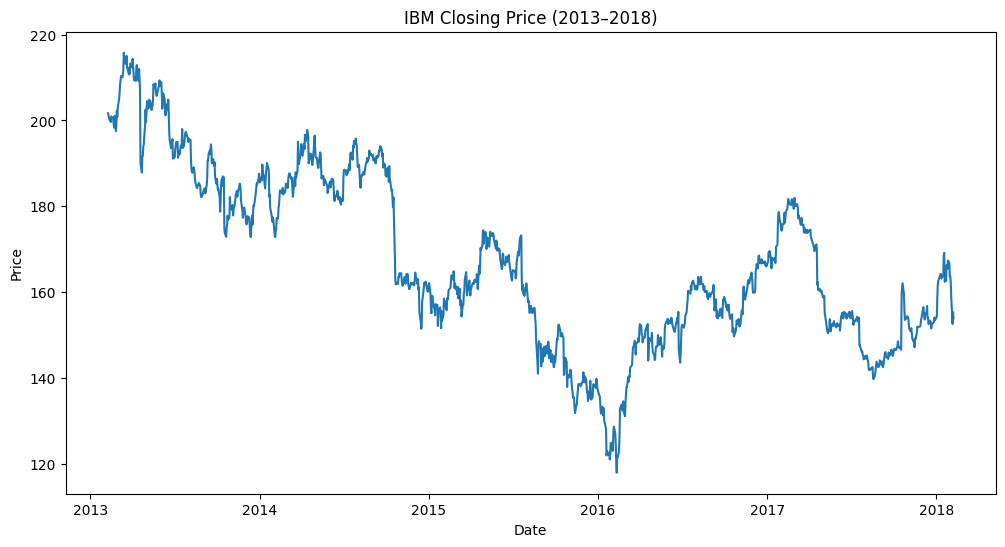

In [5]:
plt.figure(figsize=(12,6))
plt.plot(ibm.index, ibm["close"])
plt.title("IBM Closing Price (2013–2018)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Log Transformation

Log transformation stabilises variance and prepares the data for return calculations.

In [6]:
ibm["log_price"] = np.log(ibm["close"])

## Log Returns

Log returns are calculated to remove trends and produce a more stationary series.

In [7]:
ibm["log_return"] = ibm["log_price"].diff()
ibm.dropna(inplace=True)

## Visualising Log Returns

Returns typically fluctuate around zero and exhibit less trend than prices.

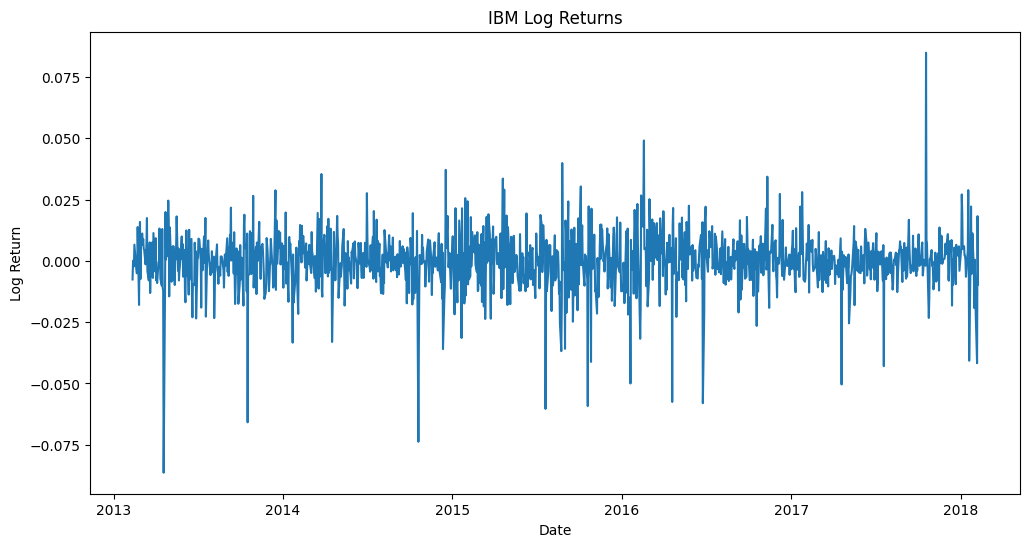

In [8]:
plt.figure(figsize=(12,6))
plt.plot(ibm.index, ibm["log_return"])
plt.title("IBM Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.show()

## Summary Statistics

Basic descriptive statistics of the transformed data.

In [9]:
print(ibm.describe())

             close    log_price   log_return
count  1258.000000  1258.000000  1258.000000
mean    167.234567     5.112133    -0.000215
std      20.191803     0.120626     0.011929
min     117.850000     4.769413    -0.086419
25%     152.432500     5.026722    -0.006090
50%     162.670000     5.091724     0.000113
75%     184.345000     5.216809     0.006144
max     215.800000     5.374352     0.084934


## Stationarity Testing (ADF Test)

The Augmented Dickey-Fuller test is used to determine whether a time series is stationary.

- Null hypothesis: series is non-stationary
- If p-value < 0.05 → reject null → stationary

In [10]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series)
    print(f"\nADF Test: {name}")
    print(f"Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")

adf_test(ibm["close"], "IBM Close Price")
adf_test(ibm["log_return"], "IBM Log Returns")


ADF Test: IBM Close Price
Statistic: -2.0493245917964518
p-value: 0.26537318225394557
Critical Values:
   1%: -3.4355629707955395
   5%: -2.863842063387667
   10%: -2.567995644141416

ADF Test: IBM Log Returns
Statistic: -25.813609342599865
p-value: 0.0
Critical Values:
   1%: -3.4355671297788666
   5%: -2.8638438984080117
   10%: -2.5679966213893057


## Autocorrelation Analysis

ACF and PACF plots are used to detect dependencies in the time series.

- ACF: correlation with past values
- PACF: partial correlation controlling for intermediate lags

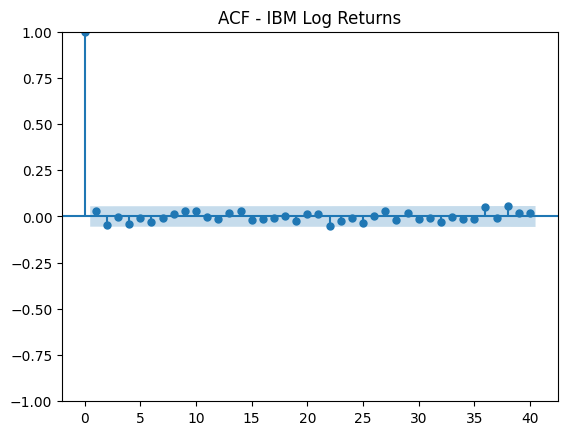

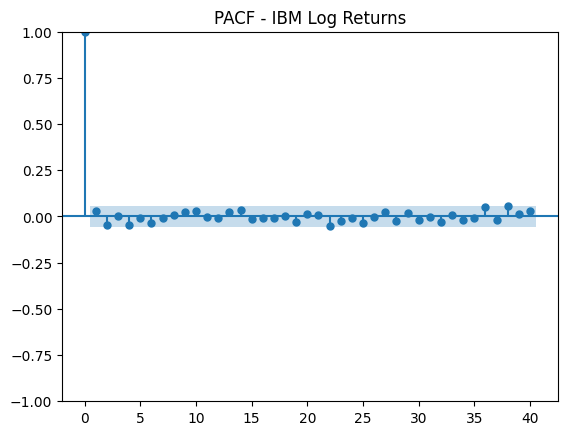

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ibm["log_return"], lags=40)
plt.title("ACF - IBM Log Returns")
plt.show()

plot_pacf(ibm["log_return"], lags=40)
plt.title("PACF - IBM Log Returns")
plt.show()

## Volatility Clustering

Squared returns are analysed to detect time-varying volatility.

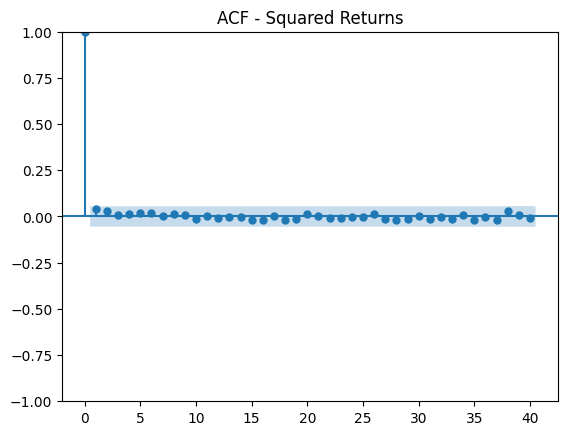

In [12]:
ibm["squared_return"] = ibm["log_return"] ** 2

plot_acf(ibm["squared_return"], lags=40)
plt.title("ACF - Squared Returns")
plt.show()

## Short Lag Analysis

Zooming into early lags to check for subtle autocorrelation patterns.

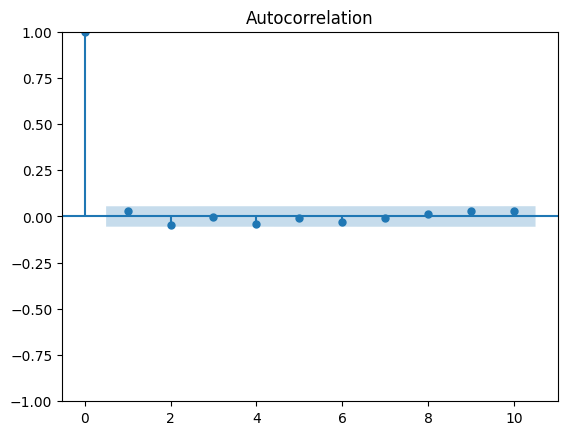

In [13]:
plot_acf(ibm["log_return"], lags=10)
plt.show()

# Interpretation

The ACF and PACF plots of log returns show no significant autocorrelation beyond the first lag, indicating that returns are approximately uncorrelated over time. Furthermore, the absence of autocorrelation in squared returns suggests limited evidence of volatility clustering. These findings imply that the series behaves similarly to white noise, supporting the weak-form Efficient Market Hypothesis.

---

# Summary In plain English

## For IBM stocks (2013–2018):

Past returns do not help predict future returns

Volatility is not strongly time-dependent

The series is close to independent random noise